In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
AAPL = pd.read_csv("../data/raw/AAPL.csv")
AMZN = pd.read_csv("../data/raw/AMZN.csv")
GOOG = pd.read_csv("../data/raw/GOOG.csv")
META = pd.read_csv("../data/raw/META.csv")
NVDA = pd.read_csv("../data/raw/NVDA.csv")

In [6]:
AAPL["stock"] = "AAPL"
AMZN["stock"] = "AMZN"
GOOG["stock"] = "GOOG"
META["stock"] = "META"
NVDA["stock"] = "NVDA"

In [7]:
stocks = pd.concat([AAPL, AMZN, GOOG, META, NVDA])

In [8]:
stocks["Date"] = pd.to_datetime(stocks["Date"])

In [9]:
stocks = stocks.sort_values(["stock","Date"])

In [10]:
stocks["SMA_20"] = stocks.groupby("stock")["Close"].transform(
    lambda x: x.rolling(20).mean()
)

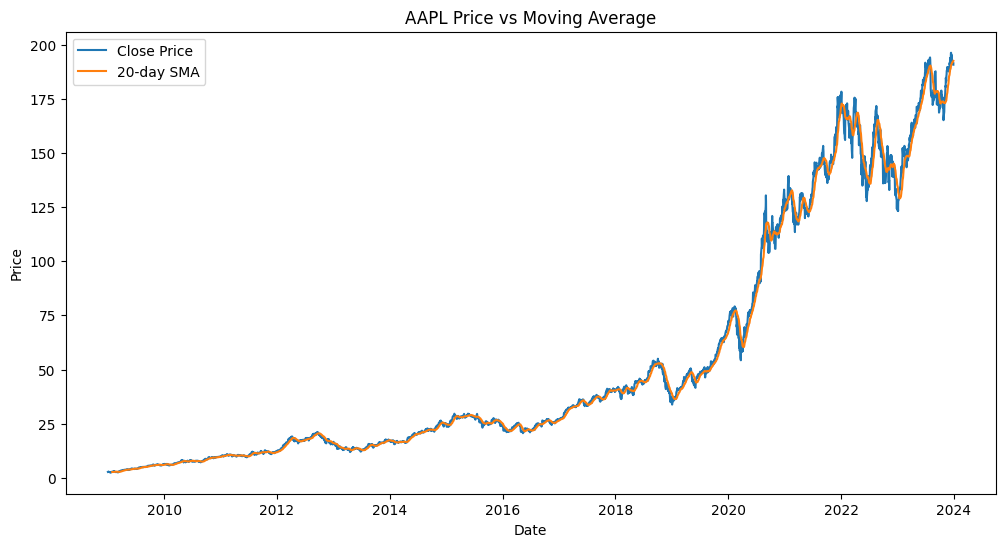

In [11]:
apple = stocks[stocks["stock"] == "AAPL"]

plt.figure(figsize=(12,6))
plt.plot(apple["Date"], apple["Close"], label="Close Price")
plt.plot(apple["Date"], apple["SMA_20"], label="20-day SMA")

plt.legend()
plt.title("AAPL Price vs Moving Average")
plt.xlabel("Date")
plt.ylabel("Price")
plt.show()

In [12]:
import pandas as pd

stocks = []

tickers = ["AAPL","AMZN","GOOG","META","NVDA"]

for t in tickers:
    df = pd.read_csv(f"../data/raw/{t}.csv")
    df["stock"] = t
    stocks.append(df)

stocks = pd.concat(stocks)

stocks["Date"] = pd.to_datetime(stocks["Date"])

stocks.head()

,Date,Close,High,Low,Open,Volume,stock
0,2009-01-02,2.721686,2.730385,2.554037,2.575630,746015200,AAPL
1,2009-01-05,2.836553,2.884539,2.780469,2.794266,1181608400,AAPL
2,2009-01-06,2.789767,2.914229,2.770872,2.877641,1289310400,AAPL
3,2009-01-07,2.729484,2.774170,2.706990,2.753477,753048800,AAPL
4,2009-01-08,2.780169,2.793666,2.700393,2.712090,673500800,AAPL


In [13]:
stocks.isnull().sum()

Date      0
Close     0
High      0
Low       0
Open      0
Volume    0
stock     0
dtype: int64

In [14]:
stocks = stocks.dropna()

In [15]:
stocks["SMA20"] = stocks.groupby("stock")["Close"].transform(
    lambda x: x.rolling(20).mean()
)

stocks["SMA50"] = stocks.groupby("stock")["Close"].transform(
    lambda x: x.rolling(50).mean()
)

In [16]:
stocks["EMA20"] = stocks.groupby("stock")["Close"].transform(
    lambda x: x.ewm(span=20, adjust=False).mean()
)

In [17]:
import numpy as np

def compute_rsi(series, window=14):

    delta = series.diff()

    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)

    avg_gain = gain.rolling(window).mean()
    avg_loss = loss.rolling(window).mean()

    rs = avg_gain / avg_loss

    rsi = 100 - (100 / (1 + rs))

    return rsi

stocks["RSI"] = stocks.groupby("stock")["Close"].transform(compute_rsi)

In [18]:
exp1 = stocks.groupby("stock")["Close"].transform(
    lambda x: x.ewm(span=12, adjust=False).mean()
)

exp2 = stocks.groupby("stock")["Close"].transform(
    lambda x: x.ewm(span=26, adjust=False).mean()
)

stocks["MACD"] = exp1 - exp2

stocks["Signal"] = stocks.groupby("stock")["MACD"].transform(
    lambda x: x.ewm(span=9, adjust=False).mean()
)

In [19]:
stocks["daily_return"] = stocks.groupby("stock")["Adj Close"].pct_change() * 100

KeyError: 'Column not found: Adj Close'

In [20]:
stocks.columns

Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'stock', 'SMA20',
       'SMA50', 'EMA20', 'RSI', 'MACD', 'Signal'],
      dtype='str')

In [21]:
stocks["daily_return"] = stocks.groupby("stock")["Close"].pct_change() * 100

In [22]:
stocks[["Date","stock","Close","daily_return"]].head()

,Date,stock,Close,daily_return
0,2009-01-02,AAPL,2.721686,NaN
1,2009-01-05,AAPL,2.836553,4.220416
2,2009-01-06,AAPL,2.789767,-1.649399
3,2009-01-07,AAPL,2.729484,-2.160860
4,2009-01-08,AAPL,2.780169,1.856959


In [23]:
stocks = stocks.dropna(subset=["daily_return"])

In [24]:
stocks.describe()

,Date,Close,High,Low,Open,Volume,SMA20,SMA50,EMA20,RSI,MACD,Signal,daily_return
count,18014,18014.000000,18014.000000,18014.000000,18014.000000,1.801400e+04,17924.000000,17774.000000,18014.000000,17949.000000,18014.000000,18014.000000,18014.000000
mean,2016-10-10 01:10:06.328411,61.216846,61.927821,60.468584,61.193499,2.018293e+08,61.039567,60.806928,60.785660,55.074239,0.310781,0.307676,0.130206
min,2009-01-05 00:00:00,0.165269,0.171228,0.162289,0.165269,1.584340e+05,0.183366,0.191038,0.183302,2.978764,-28.868349,-26.896846,-26.390092
25%,2013-04-08 06:00:00,10.856259,10.956837,10.711375,10.839571,4.001065e+07,10.939744,10.971516,10.701776,42.693135,-0.081841,-0.070897,-0.910259
50%,2016-11-01 00:00:00,28.124443,28.461012,27.833835,28.153955,8.993700e+07,28.156148,28.146385,28.030658,55.408777,0.106792,0.106592,0.100764
75%,2020-06-03 00:00:00,96.932854,98.045767,95.500000,96.877373,2.774120e+08,96.835806,96.283153,96.662587,67.434032,0.685386,0.658476,1.196188
max,2023-12-29 00:00:00,379.838379,381.975166,376.488998,379.341431,3.692928e+09,371.134071,361.525703,370.579894,99.428879,15.527799,13.061781,29.806712
std,NaN,71.244127,72.107229,70.348887,71.211470,2.615553e+08,70.869679,70.354529,70.756196,16.813712,2.183296,2.066087,2.257146


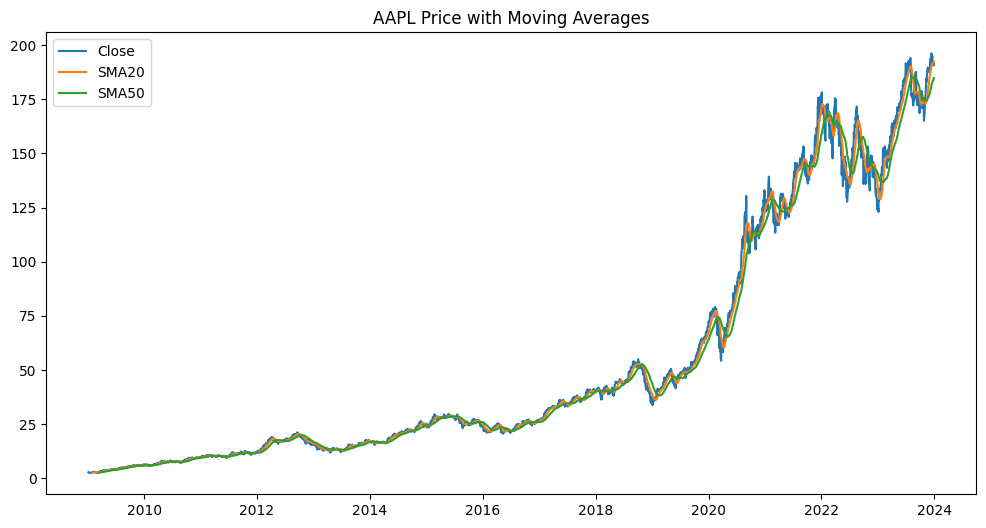

In [25]:
import matplotlib.pyplot as plt

apple = stocks[stocks["stock"]=="AAPL"]

plt.figure(figsize=(12,6))

plt.plot(apple["Date"], apple["Close"], label="Close")

plt.plot(apple["Date"], apple["SMA20"], label="SMA20")

plt.plot(apple["Date"], apple["SMA50"], label="SMA50")

plt.legend()

plt.title("AAPL Price with Moving Averages")

plt.show()

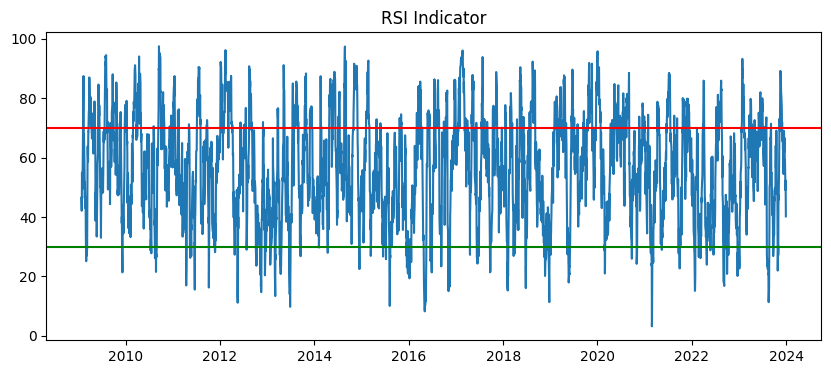

In [26]:
plt.figure(figsize=(10,4))

plt.plot(apple["Date"], apple["RSI"])

plt.axhline(70, color='red')

plt.axhline(30, color='green')

plt.title("RSI Indicator")

plt.show()

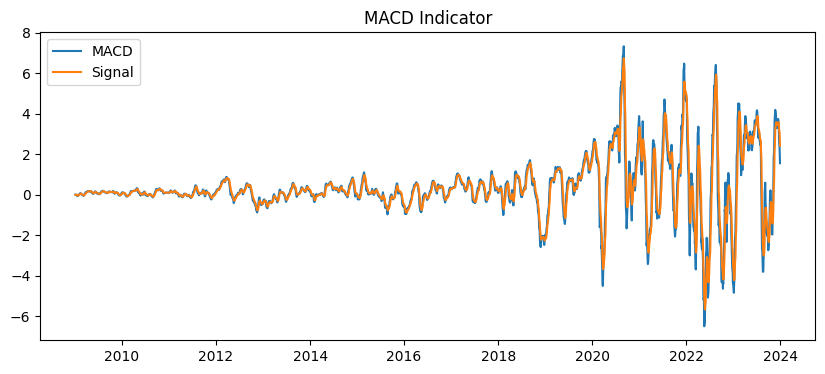

In [27]:
plt.figure(figsize=(10,4))

plt.plot(apple["Date"], apple["MACD"], label="MACD")

plt.plot(apple["Date"], apple["Signal"], label="Signal")

plt.legend()

plt.title("MACD Indicator")

plt.show()